# Segmentarea imaginilor [pe regiuni]

Segmentarea este una dintre cele mai importante etape in analiza imaginilor. Segmentarea imaginilor este procesul prin care scena este impartita in obiecte sau grupuri de obiecte componente pe baza unor similaritati intre acestea. In functie de modul de alegere al criteriului de similaritate se poate vorbi despre segmentare orientata pe regiuni sau segmentare orientata pe contururi. In cele ce urmeaza ne vom axa pe prima categorie: segmentarea orientata pe regiuni.

## 1.1. Segmentarea cu prag [pe histograma]
Cel mai simplu mod de a imparti o imagine in obiecte componente este acela in care se presupune ca obiectele au culori/valori diferite. In acest caz o simpla impartire a pixelilor in functie de valorile pe care le contin poate duce la o segmentare rezonabila.
Pentru simplitate sa presupunem ca avem de-a face cu o imagine in care avem obiecte intunecate pe un fundal luminos, asa cum este imaginea din figura 1.1a) si ca dorim sa separam obiectele de fundal. In acest caz este de ajuns sa luam in considerare numai planul de luminozitate (vezi figura 1.1b)). In planul de luminozitate se vede clar ca pixelii mai intunecati apartin obiectelor, pe cand cei luminosi apartin fundalului. Dar ce inseamna <i>mai luminosi</i> si <i>mai intunecati</i>? Pentru a gasi o masura a cat de luminos trebuie sa fie un pixel pentru a apartine sau nu fundalului, vom construi histograma (vez figura 1.1c)). In graficul histogramei observam o impartire a nivelelor de gri din imagine in doa zone: sunt multi pixeli care contin niveluri de gri in jurul valorii de 50 (acestia provin de la jucarii care sunt mai intunecate) si multi care au valori in jurul nivelului de 200 (acestia provin de la fundal). Asadar putem sa presupunem ca tot ce are nivel de gri pana la 120-150 (un minim intre cele doua maxime importante), provine de la jucarii (zonele intunecate ale imaginii), tot ce are valori egale sau peste acest prag provine de la fundalul luminos. Vom alege ca prag valoarea de 150. Vom eticheta diferit pixelii in functie de ce valoare au relativ la acest prag: daca initial avea nivel de gri mai mic de 150 le vom da eticheta 1, altfel le vom da eticheta 256. Operatia pe care tocmai am facut-o se numeste segmentare pe histograma. Rezultatul acestei operatii se poate observa in figura 1.1d).

<img src="segm_lumin.png"><center>Figura 1.1: a) Exemplu de imagine in care obiectele au luminozitatea diferita de fundal. b) Planul de luminozitate al imaginii. c) Histograma imaginii. d) Rezultatul segmentarii pe luminozitate cu prag 150.</center>

Evident aceasta metoda poate da rezultate acceptabile numai in conditiile in care informatia de luminozitate caracterizeaza in mod suficient obiectele din scena. Doar in acest caz histograma de luminozitate va prezenta moduri dominante (intervale de niveluri de gri ce apar cu probabilitate mare) ce vor putea fi separate prin punerea de praguri. Intotdeauna pragurile se vor alege in minimele locale ale histogramei, pentru a separa aceste moduri. Trebuie remarcat de asemenea ca trebuie cunoscut dinainte numarul de obiecte care se doresc a fi diferentiate pentru alegerea corespunzatoare a numarului de praguri de segmentare.


### Exercitiul 1: Implementati exemplul prezentat. Se poate determina numarul de obiecte din imagine? Se putea face segmentarea separata a obiectelor direct pe planul de luminanta? Dar pe un plan de culoare? Dar pe nuanta?
Pentru rezolvarea acestui exercitiu este nevoie de cateva functii auxiliare. Numpy are o functie de calcul a histogramei pentru o imagine scalara (cu un singur plan):
```python
hist,_ = np.histogram(img,........)
```
Pentru a evita folosirea a doua bucle ```for``` pentru a parcurge imaginea se poate utiliza indexarea numpy. Ex.:
```python
A = np.array([[1,2,0],[0,2,1],[1,0,1]])
B = A.copy()
B[A>0] = 100
print(B)

#Daca se doresc conditii multiple trebuie utilizata functia np.logical_and
B = A.copy()
B[np.logical_and(A>0,A<2)]=100
print(B)
```

Similar, pentru conditii simple, se poate genera direct
```python
A = np.array([[1,2,0],[0,2,1],[1,0,1]])
B = 100*np.uint8(A>0)
print(B)
```
Rularea acestui cod are drept consecinta modificarea matricei B la locatiile unde matricea A are valori >0.

De asemenea, avand o imagine segmentata care are 0 pe fundal si valori >0 pentru obiecte, functia ```measure.label(A)``` va pune etichete unice pentru fiecare obiect in parte. Modulul ```measure``` este parte din scikit-image:
```python
from skimage import io,color,measure

#...
L = measure.label(A)
```

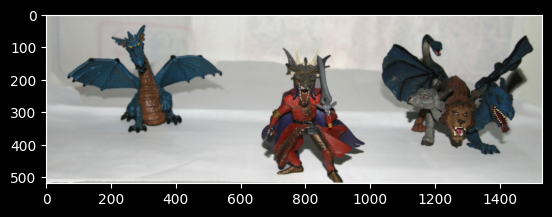

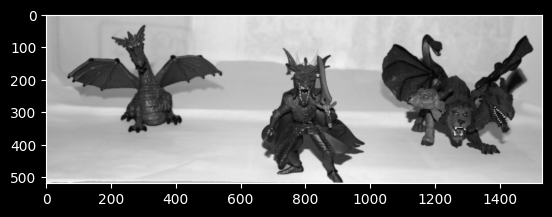

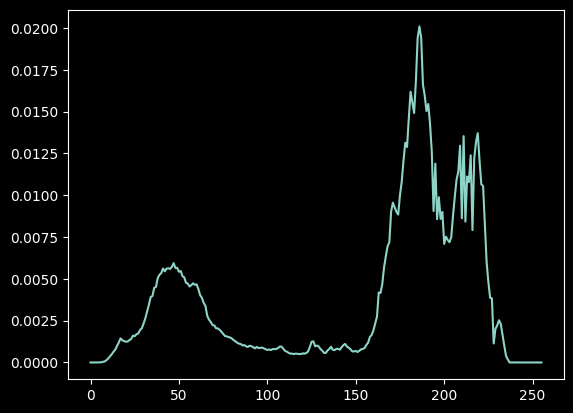

(<Figure size 640x480 with 1 Axes>,
 None)

In [2]:
import numpy as np
from skimage import io,color
import matplotlib.pyplot as plt
from scipy import signal
plt.style.use('dark_background')

img=io.imread('../poza1.jpg')
plt.figure(), plt.imshow(img), plt.show()

Y = np.uint8(255*color.rgb2gray(img))
plt.figure(), plt.imshow(Y, cmap='gray'), plt.show()

hist,_ = np.histogram(Y,bins=256,range=(0,256))
hist = hist/np.sum(hist)
plt.figure(), plt.plot(hist), plt.show()


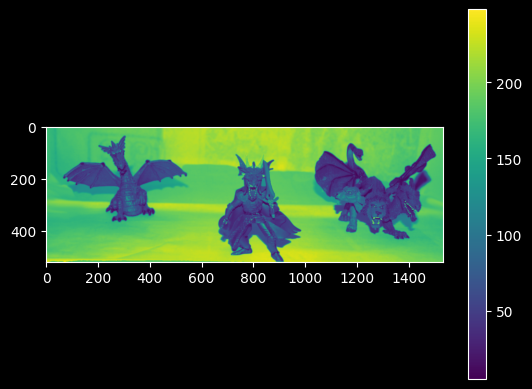

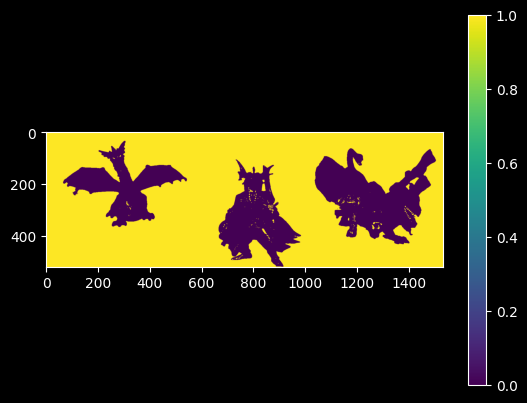

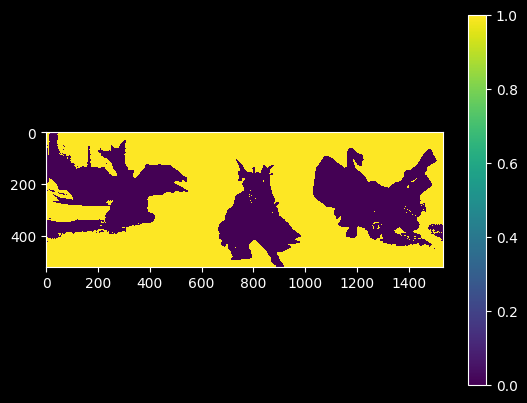

(<Figure size 640x480 with 2 Axes>,
 None)

In [3]:
plt.figure(), plt.imshow(Y), plt.colorbar(), plt.show()
plt.figure(), plt.imshow(Y>120), plt.colorbar(), plt.show()

# efect de aliere (zone de albastru, imaginea nu e binarizata)
plt.figure(), plt.imshow(Y>170, interpolation='none'), plt.colorbar(), plt.show()

### Exercitiul 2: Sa se lucreze un alt exemplu in care segmentarea pe planul de luminozitate cu mai multe praguri de rezultate acceptabile si sa se faca segmentarea.

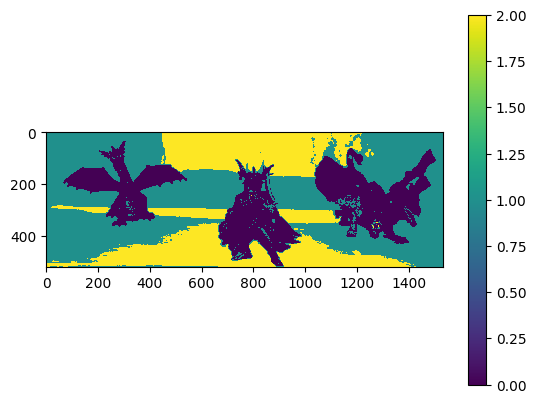

(<Figure size 640x480 with 2 Axes>,
 None)

In [5]:
# cu if
[linii, coloane] = np.shape(Y)

out = np.zeros((linii,coloane))
prag1 = 100
prag2 = 200
for l in range(linii): 
    for c in range(coloane):
        if Y[l,c] >= prag1 and Y[l,c] < prag2:
            out[l,c] = 1
        elif Y[l,c] >= prag2:
            out[l,c] = 2

plt.figure(), plt.imshow(out, interpolation='none'), plt.colorbar(), plt.show()

### Exercitiul 3: Separati semnele de interzis din imaginea <i>semnecirculatie.jpg</i>

In [6]:
# acasa ?

### Exercitiul 4: Segmentati cu prag o imagine naturala color.
Extinderea tehnicii cu prag implica aplicarea unui prag pe fiecare plan de culoare.
Un exemplu tipic este segmentarea in imagini color a zonelor de culoarea pielii umane. Un model simplu de segmentare in spatiul RGB pleaca de la presupunerea R > 95 si G > 40 si B > 20. Verificati.

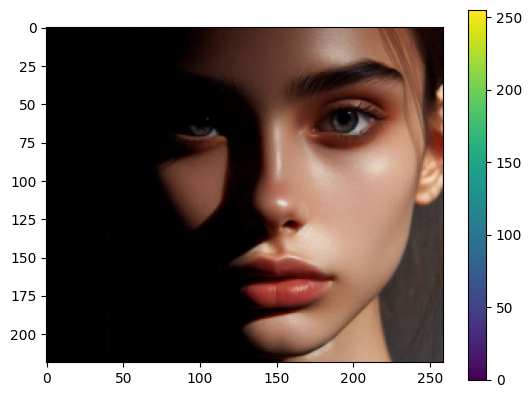

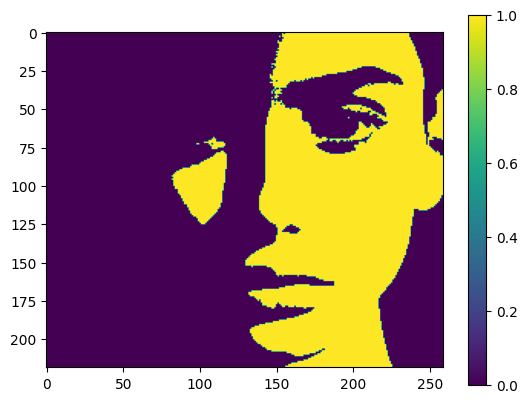

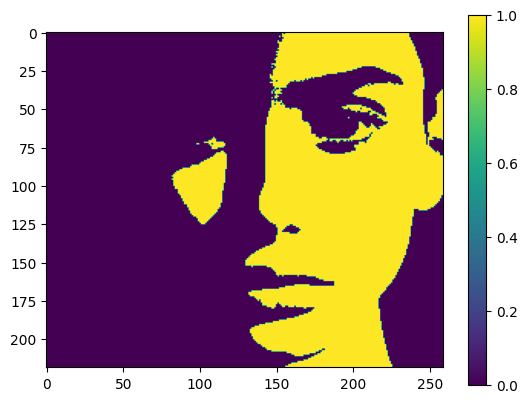

(<Figure size 640x480 with 2 Axes>,
 None)

In [7]:
img = io.imread('uneven-face-mic.png')
plt.figure(), plt.imshow(img), plt.colorbar(), plt.show()

L,C,pl = np.shape(img)
imgout1 = np.zeros((L,C))

for l in range(L):
    for c in range(C):
        if img[l,c,0] > 95 and img[l,c,1] > 40 and img[l,c,2] > 20:
            imgout1[l,c]=1

plt.figure(), plt.imshow(imgout1), plt.colorbar(), plt.show()

# sau

img = img[:,:,0:3]
T = np.zeros((1,1,3))
T[0,0,0] = 95
T[0,0,1] = 40
T[0,0,2] = 20

imgout = img > T
plt.figure(), plt.imshow(np.prod(np.float64(imgout), axis = 2)), plt.colorbar(), plt.show() # facem produs ca sa avem doar 0 si 1
# by default produsul va fi 0, daca conditia e adevarata pt un plan sau 2 planuri, atunci produsul va fi 1

In mod evident, doar praguri simple pe planele de culoare considerate separat nu rezolva problema. Trebuie adaugate conditii simultane la mai multe plane: R>B si R-G>15.

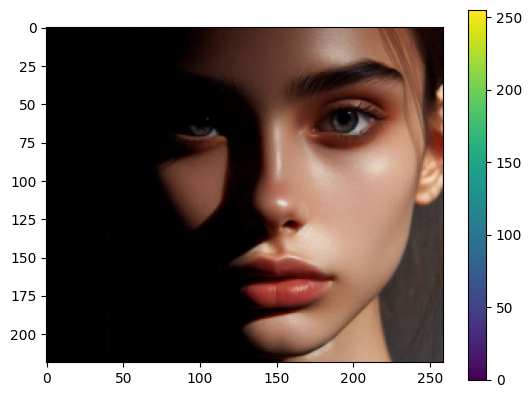

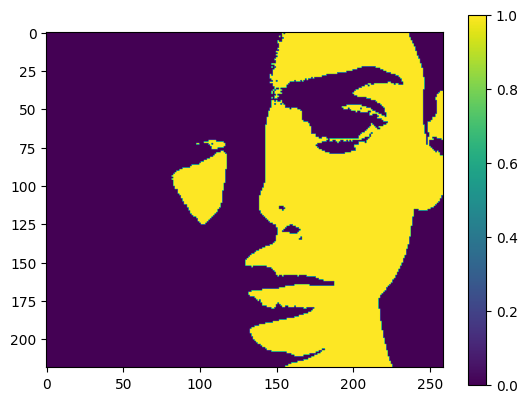

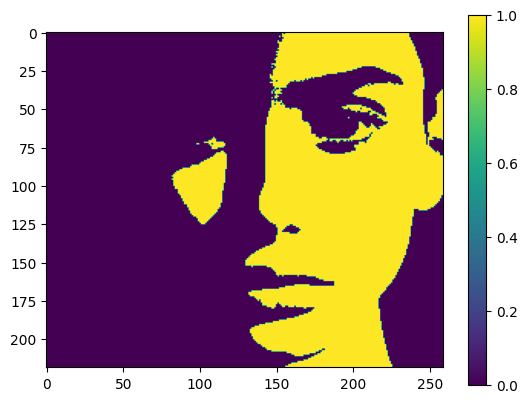

(<Figure size 640x480 with 2 Axes>,
 None)

In [10]:
img = io.imread('uneven-face-mic.png')
plt.figure(), plt.imshow(img), plt.colorbar(), plt.show()

L,C,pl = np.shape(img)
imgout2 = np.zeros((L,C))

for l in range(L):
    for c in range(C):
        if img[l,c,0] > 95 and img[l,c,1] > 40 and img[l,c,2] > 20 and img[l,c,0] > img[l,c,2] and img[l,c,0] - img[l,c,1] > 15:
            imgout2[l,c]=1

plt.figure(), plt.imshow(imgout2), plt.colorbar(), plt.show()
plt.figure(), plt.imshow(imgout1), plt.colorbar(), plt.show()

## 1.2 Segmentarea in spatiul de culoare

### Algoritmi de clustering

Clustering inseamna gruparea punctelor similare si eventual reprezentarea lor printr-un singur punct numit centroid.

Punerea problemei: Avand un set de pixeli (sau generic date), fiecare dintre ei caracterizat de mai multe trasaturi, dorim gruparea acestora prin conditii de similaritate. Toti pixelii cu vectori de trasaturi ce au valori asemanatoare vor capata o aceeasi eticheta, formand un grup (un cluster). Suplimentar, pentru fiecare grup, este posibila determinarea unui reprezentant tipic care sa aproximeze pixelii din grupul respectiv.

Daca consideram ca obiectivul clusterizarii este acela de a gasi centroizii care aproximeaza cel mai bine clasele de puncte atunci calitatea rezultatului (sau functia obiectiv) este data de suma distantelor de la fiecare punct la centroidul clasei in care a fost asignat de catre algoritmul de clusterizare. In mod evident aceasta suma vrem sa fie minima.

### Algoritmul K-means (a.k.a. C-means, ISODATA)

Daca avem un vector de date $x_i$, cu $ i=1..N $ si vrem sa il impartim in $K$ partitii (clase), atunci dupa clusterizare fiecare pixel va avea asignata o clasa din cele $K$ dorite. Vom nota cu $x^{(j)}_i$ faptul ca pixelul $i$ a fost asignat clasei $j$. Pentru fiecare clasa (grup) obtinut, avem un centroi notat cu $c_j$. Asadar functia obiectiv ce vrem sa fie minimizata este:

$ J = \sum^K_{j=1}{\sum^N_{i=1} { || x^{(j)}_i - c_j ||^2  }} $

unde $ || x^{(j)}_i - c_j ||^2 $ este distanta dintre punctul $i$ asignat clasei $j$ si centroidul acelei clasei, $c_j$. 

Algoritmul la care se ajunge, este un algoritm iterativ, astfel:

Pasul 1: Se intializeaza centroizii, $c_j$ (sau se asigneaza aleator clasa fiecarui pixel). 

Pasul 2: Se calculeaza distantele de la fiecare punct la fiecare centroid si se alege clasa centroidului ce a dat distanta minima.

Pasul 3: Se recalculeaza centroizii ca fiind media punctelor asignate fiecarei clase.

Pasul 4: Se repeta pasii 2 si 3 pana cand se ajunge la convergenta.


### Modul de functionare al K-means - segmentarea imaginilor color
In cazul imaginilor True Color, fiecare pixel este caracterizat de un vector de 3 numere - cantitatile de rosu, verde si albastru ale culorii pixelului. Cele trei componente de culoare pot fi considerate vector de trasaturi pentru pixelul respectiv.

Asadar in cele ce urmeaza vom face o segmentare a pixelilor cu ajutorul algoritmului K-means considerand ca vectori de trasaturi chiar informatiile de culoare ale acestora.

Implementarea algoritmului K-means din biblioteca sklearn este urmatoarea:
```python
kmeans = cluster.KMeans(n_clusters=K, random_state = None, n_init = 1).fit(data)
```
n_clusters=K # in cate clase imparte datele

random_state = None # initializeaza aleator (daca se doreste initializarea identica la 2 rulari se va folosi un numar intreg)

n_init = 1 # de cate ori repeta algoritmul (atentie nu este numarul de iteratii pana la convergenta, ci de cate ori ruleaza intreg algoritmul). Algoritmul se poate opri in minime locale ale functie cost. De aceea se recomanda mai multe rulari si alegerea acelei rulari care a dat functia cost minima la convergenta.

data = setul de vectori de grupat (vectorii se dau pe LINIILE matricii data)

kmeans = structura de date ce contine rezultatul (are mai multe atribute, precum cluster_centers_ si labels_)

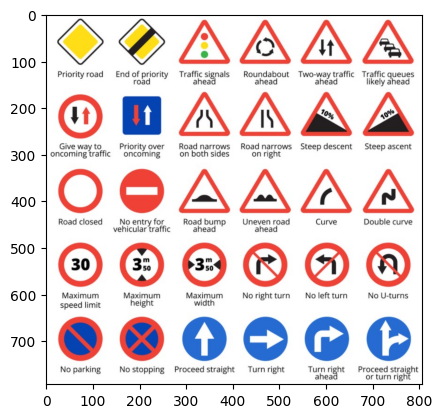

(639951,)
(639951, 3)


In [16]:
import numpy as np
from skimage import io, measure
import matplotlib.pyplot as plt
from sklearn import cluster,datasets

# citim o imagine color
#img=io.imread('lenamic.png')
img=io.imread('semnecirculatie.jpg')
img=img[:,:,0:3]
plt.figure(),plt.imshow(img),plt.show()
dims = np.shape(img)

# luam separat planurile de culoare
R = img[:,:,0]
G = img[:,:,1]
B = img[:,:,2]
# le vectorizam 
r = np.ndarray.flatten(R[:])
print(np.shape(r))
g=np.ndarray.flatten(G[:])
b=np.ndarray.flatten(B[:])

# ne formam setul de date
data = np.transpose(np.array([r,g,b]))
print(np.shape(data))

[[194.91222291 167.55940939 163.1547047 ]
 [253.35569044 252.84078837 252.60624448]
 [ 30.84563598  94.29260046 196.41132821]
 [233.90259053  79.22423708  57.56375966]
 [ 56.65545207  53.15663845  54.11587633]]


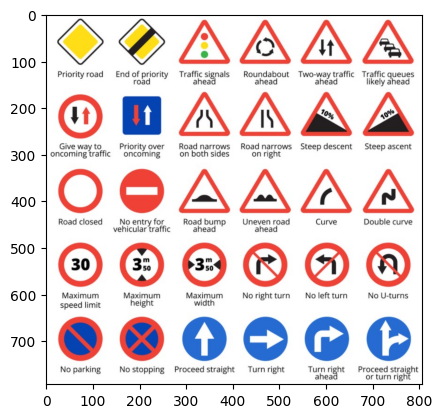

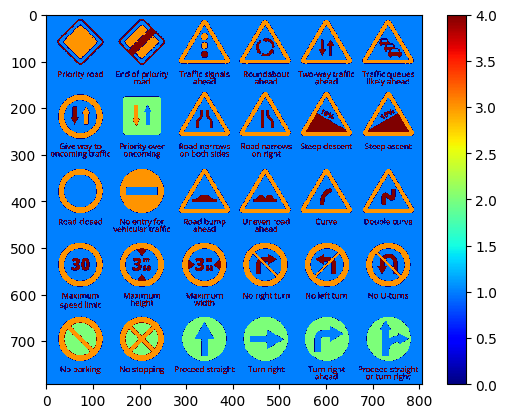

(<Figure size 640x480 with 2 Axes>,
 None)

In [47]:
K = 5
kmeans = cluster.KMeans(n_clusters=K, random_state=None).fit(data)
etichete = kmeans.labels_
centroizi = kmeans.cluster_centers_
print(centroizi)

plt.figure(), plt.imshow(img), plt.show()
plt.figure(), plt.imshow(np.reshape(etichete, (dims[0],dims[1])), cmap="jet",interpolation='none'), plt.colorbar(), plt.show()

### Exercitiul 5
Sa se genereze o imagine color care aproximeaza imaginea coor intiala, inlocuind culoarea fiecarui pixel original cu centroidul clasei la care acest pixel apartine conform unui clustering cu K clase.
Sa se reprezinte grafic calitatea imaginii color aproximate din centroizi in functie de numarul de K clase.

### Exercitiul 6
Reluati segmentarea prin clustering in diferite spatii de culoare